# Tarea Práctica: Backtesting y Mitigación de Drift en Modelos de Seguros

---

## Contexto del Negocio

Trabajas como Data Scientist / Actuario de Machine Learning en una aseguradora de autos. La dirección comercial implementó a finales de 2023 un nuevo canal de ventas digital que atrajo a conductores más jóvenes y con perfiles de manejo distintos a la cartera tradicional.

Tu tarea es evaluar el modelo de severidad de siniestros de auto puesto en producción en 2023 y corregir la degradación que sufrió durante el año 2024–2025 mediante técnicas de validación temporal y mitigación de drift.

|Encargados del proyecto|
|----------------|
| Alondra Abril Alarcón Alvarez |
| Angelica Guadalupe Cravioto Perez|
| Arturo Cortés Islas | 
| Dereck Favila Limón |
| Ismael Ruiz Carbajal |
| José Julián Alcalá Alcántara |
| Melissa González Cortés |

**Seguimiento:**

[1. Generación / Carga de Datos](#1-datos)

[2. Backtesting Inicial (Out-of-Time)](#2-backtesting)

[3.	Diagnóstico](#3-diagnostico)

[4.	Propuesta de Corrección (Implementar al menos UNA solución)](#4-correccion)

[5.	Reporte](#5-reporte)

[6.	Haz el mismo ejercicio pero escoge otro modelo](#6-same)

[7.	Rúbrica de Evaluación para cada modelo](#7-rubrica)




<a id='1-datos'></a>
### **1.	Generación / Carga de Datos:** 

Corre la celda de Python provista para generar el dataset de siniestros de autos (2021–2025).

In [60]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(2026)
n = 30000
# Generación de fechas de siniestros, edades de conductores, tipos de vehículos y antigüedad de autos
fechas = pd.date_range(start='2021-01-01', end='2025-12-31', periods=n)
edad_conductor = np.random.randint(18, 70, size=n)
tipo_vehiculo = np.random.choice(['Sedan', 'SUV', 'Deportivo'], size=n, p=[0.5, 0.4, 0.1])
antiguedad_auto = np.random.randint(0, 15, size=n)

# Creación del DataFrame con los datos simulados
df_tarea = pd.DataFrame({
    'fecha_siniestro': fechas,
    'edad_conductor': edad_conductor,
    'tipo_vehiculo': tipo_vehiculo,
    'antiguedad_auto': antiguedad_auto
})

# Cambio estructural en la cartera a partir de 2024 (Entran conductores más jóvenes)
mascara_2024 = df_tarea['fecha_siniestro'] >= '2024-01-01'
# Actualización de las edades de los conductores
df_tarea.loc[mascara_2024, 'edad_conductor'] = np.random.randint(18, 35, size=mascara_2024.sum())

# Inflación de Refacciones Automotrices (Índice de Costos)
df_tarea['año'] = df_tarea['fecha_siniestro'].dt.year
# Mapa de inflación por año
mapa_inflacion = {2021: 1.00, 2022: 1.07, 2023: 1.15, 2024: 1.28, 2025: 1.42}
df_tarea['indice_costo_refaccion'] = df_tarea['año'].map(mapa_inflacion)

# Generación del costo real del siniestro
val_vehiculo = df_tarea['tipo_vehiculo'].map({'Sedan': 1.0, 'SUV': 1.4, 'Deportivo': 2.0})
# Costo base del siniestro considerando el tipo de vehículo, edad del conductor, antigüedad del auto y 
# un componente aleatorio 
costo_base = (
    8000 * val_vehiculo + 
    300 * (70 - df_tarea['edad_conductor']) + 
    500 * (15 - df_tarea['antiguedad_auto']) +
    np.random.normal(0, 2000, size=n)
)

# Costo de reparación real considerando el índice de inflación y un costo mínimo de 1500
df_tarea['costo_reparacion_real'] = np.maximum(1500, costo_base * df_tarea['indice_costo_refaccion'])

# Guardar o limpiar columnas que no deben ver directamente como target
df_tarea.drop(columns=['año'], inplace=True)
print("Dataset de la tarea cargado exitosamente.")


Dataset de la tarea cargado exitosamente.


In [61]:
# Visualización de las primeras filas del dataset
df_tarea.head()

,fecha_siniestro,edad_conductor,tipo_vehiculo,antiguedad_auto,indice_costo_refaccion,costo_reparacion_real
0,2021-01-01 00:00:00.000000000,19,SUV,14,1.0,28370.659317
1,2021-01-01 01:27:36.175205840,24,Sedan,1,1.0,28168.738282
2,2021-01-01 02:55:12.350411680,44,SUV,13,1.0,22255.805828
3,2021-01-01 04:22:48.525617520,31,SUV,8,1.0,27215.447180
4,2021-01-01 05:50:24.700823360,31,Deportivo,8,1.0,31477.265274


<a id='2-backtesting'></a>

### **2.	Backtesting Inicial (Out-of-Time):**

- Divide la muestra utilizando una fecha de corte (cut-off date): Entrena con datos de 2021 a 2023 y evalúa en el periodo 2024–2025.

- Entrena un modelo Gradient Boosting (XGBoost) o Random Forest o regresión.
    
- Modela el error (Error Medio Absoluto y Sesgo Promedio) por trimestre durante 2024 y 2025. ¿Qué observas a medida que avanza el tiempo?


In [62]:
# Divide el dataset en entrenamiento y prueba
# Creamos columna de año y creamos filtros para separar los datos de entrenamiento y prueba
df_tarea['año'] = df_tarea['fecha_siniestro'].dt.year
mask_tr = df_tarea['año'] < 2024
mask_va = df_tarea['año'] >= 2024

# Definimos las características que se usarán para el modelo
FEATURES = ['edad_conductor', 'tipo_vehiculo', 'antiguedad_auto']

# Creamos los conjuntos de entrenamiento y prueba
X_tr = df_tarea.loc[mask_tr, FEATURES] ; y_tr = df_tarea.loc[mask_tr, 'costo_reparacion_real']
X_va = df_tarea.loc[mask_va, FEATURES] ; y_va = df_tarea.loc[mask_va, 'costo_reparacion_real']

In [63]:
# Entrenamiento del modelo de Gradient Boosting, Random Forest y Regresión Lineal.


# Hacemos pipeline de preprocesamiento para escalar las variables numéricas y codificar las categóricas

# Diccionario de riesgo
riesgo_dict = {'Sedan': 1.0, 'SUV': 1.4, 'Deportivo': 2.0}

# Función de mapeo
def map_riesgo(X):
    X = X.copy()
    X['tipo_vehiculo'] = X['tipo_vehiculo'].map(riesgo_dict)
    return X

# Transformador
encoder = FunctionTransformer(map_riesgo)

# Preprocesador que combina escalado y codificación
preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), ['edad_conductor', 'antiguedad_auto']),
    ("encoder", encoder, ["tipo_vehiculo"])
])

# Creamos los modelos con pipelines que incluyen el preprocesamiento
modelos = {
    'GradientBoosting': Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor())]),
    'LinearRegression': Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
}

# Entrenamos los modelos 
for nombre_modelo, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    print(f"Modelo {nombre_modelo} entrenado exitosamente.")

Modelo GradientBoosting entrenado exitosamente.
Modelo LinearRegression entrenado exitosamente.


In [64]:
# Modela el Error Medio absoluto y el sesgo promedio por trimestre durante 2024 y 2025
np.random.seed(42)
ANIOS_BT = [2024, 2025]
resultados_bt = []

print("COMPARACIÓN — Holdout temporal fijo")
print(f"  Train: 2021–2023 ({mask_tr.sum():,} registros)  "
      f"Val: 2024 ({mask_va.sum():,} registros)")
print()
print(f"  {'Periodo':}  {'MAE ($K)':>10}  {'RMSE ($K)':>11}  {'R²':>8}  {'MAPE%':>7}  {'Sesgo ($K)':>10}  {'Modelo'}")
print("-"*83)

for nombre_modelo, modelo in modelos.items():
      for anio in ANIOS_BT:
            mask_año = df_tarea['año'] == anio
            for q in [1,2,3,4]:  # Trimestres
                  mask_trimestre = (df_tarea['fecha_siniestro'].dt.quarter == q) & mask_año
                  X_bt_trim = df_tarea.loc[mask_trimestre, FEATURES]
                  y_bt_trim = df_tarea.loc[mask_trimestre, 'costo_reparacion_real']
                  
                  y_pred = modelo.predict(X_bt_trim)
                  mae = np.mean(np.abs(y_bt_trim - y_pred)) / 1000  # en miles
                  rmse = np.sqrt(np.mean((y_bt_trim - y_pred) ** 2)) / 1000  # en miles
                  r2 = modelo.score(X_bt_trim, y_bt_trim)
                  mape = np.mean(np.abs((y_bt_trim - y_pred) / y_bt_trim)) * 100
                  #Sesgo
                  sesgo = np.mean(y_pred - y_bt_trim)/1000  # en miles
                  
                  resultados_bt.append({
                        'Periodo': f"{anio}",
                        'Modelo': nombre_modelo,
                        'MAE ($K)': mae,
                        'RMSE ($K)': rmse,
                        'R²': r2,
                        'MAPE%': mape,
                        'Sesgo ($K)': sesgo,
                        'Trimestre': q
                  })
                  
                  print(f"  {anio} - {q:<2} {mae:>10.2f}  {rmse:>11.2f}  {r2:>8.4f}  {mape:>7.2f} {sesgo:>10.2f} {nombre_modelo}")



COMPARACIÓN — Holdout temporal fijo
  Train: 2021–2023 (18,000 registros)  Val: 2024 (12,000 registros)

  Periodo    MAE ($K)    RMSE ($K)        R²    MAPE%  Sesgo ($K)  Modelo
-----------------------------------------------------------------------------------
  2024 - 1        5.59         6.16   -0.3205    15.56      -5.55 GradientBoosting
  2024 - 2        5.71         6.32   -0.3680    15.82      -5.67 GradientBoosting
  2024 - 3        5.80         6.36   -0.4749    16.16      -5.77 GradientBoosting
  2024 - 4        5.71         6.26   -0.4845    15.91      -5.67 GradientBoosting
  2025 - 1        9.59        10.08   -1.9985    24.16      -9.59 GradientBoosting
  2025 - 2        9.66        10.13   -1.9752    24.47      -9.65 GradientBoosting
  2025 - 3        9.64        10.13   -2.0447    24.37      -9.64 GradientBoosting
  2025 - 4        9.40         9.91   -1.7595    23.91      -9.39 GradientBoosting
  2024 - 1        5.59         6.15   -0.3169    15.54      -5.55 LinearR

Al evaluar los modelos (Gradient Boosting y Regresión Lineal) entrenados con datos de 2021 a 2023 en el periodo 2024–2025, se observa lo siguiente:

- Incertidumbre y Degradación Progresiva:
    - En 2024, el MAE (Error Medio Absoluto) ronda los $5.5K – $5.8K.  
    - En 2025, el MAE se dispara casi al doble, ubicándose entre $9.4K – $9.6K.  

- Sesgo Severo Negativo (Subestimación del Costo):
    - El Sesgo pasa de ser aproximadamente -$5.5K a inicios de 2024 a casi -$9.6K a mediados de 2025.  
    - Un sesgo crecientemente negativo indica que los modelos están sobreestimando la rentabilidad y subestimando drásticamente el costo real de reparación de los siniestros.  

<a id='3-diagnostico'></a>

### 3.	Diagnóstico:
- Demuestra analíticamente o gráficamente si el problema se debe a un cambio en la composición de la cartera (Population Drift) o a un cambio en el costo de reparación (Concept Drift / Inflación de refacciones).


Para saber si hubo cambios en la composición de la cartera, revisaremos el PSI de nuestras variables

In [65]:
# ── PSI — Population Stability Index ─────────────────────────────────────────
def calcular_psi(base_values, actual_values, n_bins=10):
    percentiles = np.linspace(0, 100, n_bins+1)
    bins        = np.percentile(base_values, percentiles)
    bins[0]    -= 1e-6;  bins[-1] += 1e-6
    bc = np.histogram(base_values,   bins=bins)[0]
    ac = np.histogram(actual_values, bins=bins)[0]
    bp = np.where(bc==0, 0.001, bc/len(base_values))
    ap = np.where(ac==0, 0.001, ac/len(actual_values))
    return np.sum((ap - bp) * np.log(ap / bp))

base_mask = df_tarea['año'].isin([2021, 2022, 2023])

print("PSI por variable — base: 2021–2023 vs cada año de producción:")
print("  < 0.10: estable  |  0.10–0.25: monitorear  |  > 0.25: cambio significativo")
print()
print(f"  {'Variable':>22}  {'2024':>8}  {'2025':>8}  {'Estado'}")
print("-"*68)

psi_resumen = {}
for feat in ['edad_conductor','antiguedad_auto']:
    bv    = df_tarea.loc[base_mask, feat].values
    psies = [calcular_psi(bv, df_tarea.loc[df_tarea['año']==a, feat].values) for a in [2024,2025]]
    psi_resumen[feat] = psies
    max_p = max(psies)
    estado = "🔴 Cambio severo" if max_p>0.50 else ("⚠️ Monitorear" if max_p>0.10 else "✅ Estable")
    print(f"  {feat:>22}  "+"  ".join(f"{p:>8.4f}" for p in psies)+f"  {estado}")

print()

PSI por variable — base: 2021–2023 vs cada año de producción:
  < 0.10: estable  |  0.10–0.25: monitorear  |  > 0.25: cambio significativo

                Variable      2024      2025  Estado
--------------------------------------------------------------------
          edad_conductor    3.4479    3.4261  🔴 Cambio severo
         antiguedad_auto    0.0012    0.0021  ✅ Estable



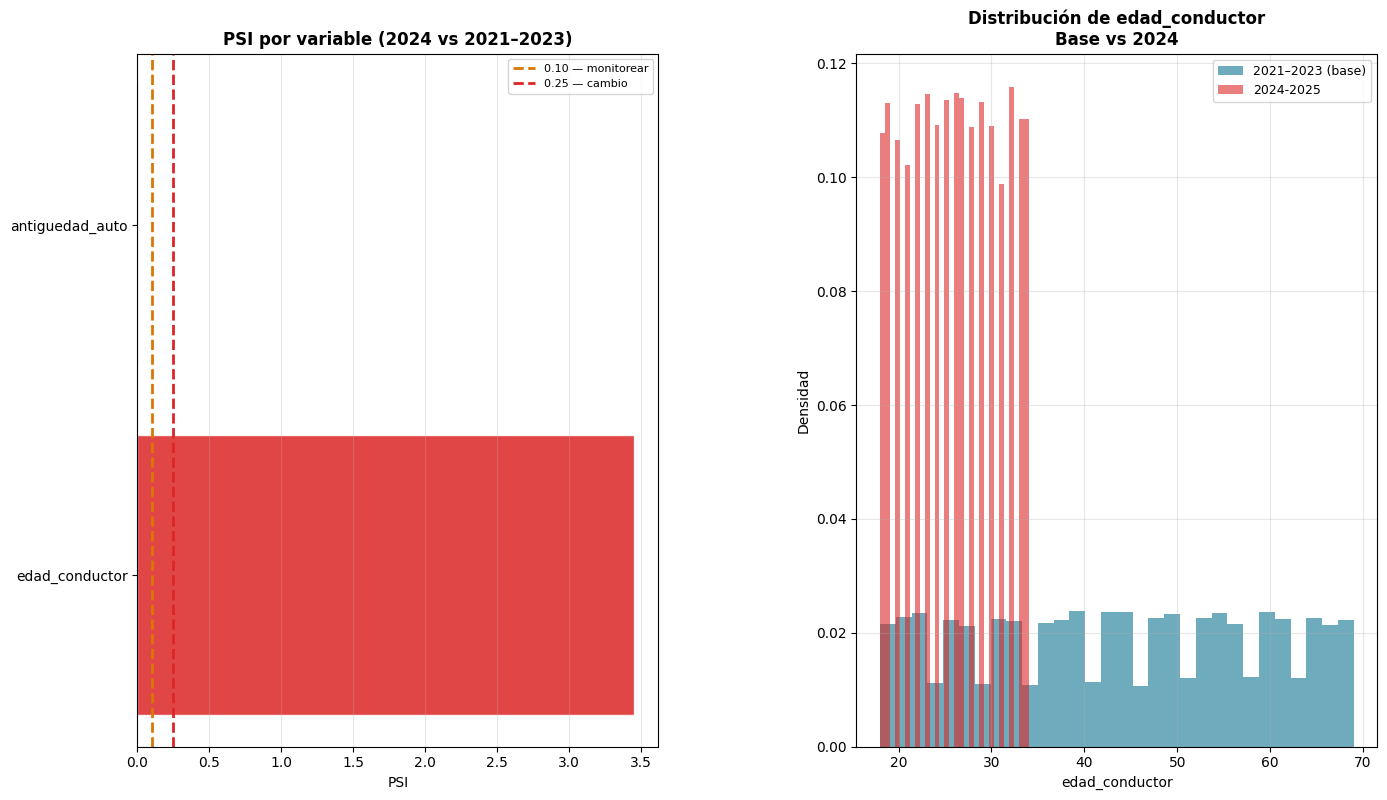

In [66]:

# Crear figura y eje
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(1,2, figure=fig, wspace=0.38, hspace=0.45)

feats_psi   = list(psi_resumen.keys())
psi_24      = [psi_resumen[f][0] for f in feats_psi]
colores_psi = ['#DC2626' if v>0.25 else ('#D97706' if v>0.10 else '#059669') for v in psi_24]

# Gráfico de barras horizontales
ax = fig.add_subplot(gs[0])
ax.barh(feats_psi, psi_24, color=colores_psi, alpha=0.85, edgecolor='white')

# Líneas verticales de referencia
ax.axvline(0.10, color='#D97706', lw=2, ls='--', label='0.10 — monitorear')
ax.axvline(0.25, color='#DC2626', lw=2, ls='--', label='0.25 — cambio')

# Títulos y etiquetas
ax.set_title('PSI por variable (2024 vs 2021–2023)', fontweight='bold')
ax.set_xlabel('PSI')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='x')



feat_max_psi = max(psi_resumen, key=lambda f: psi_resumen[f][0])
ax = fig.add_subplot(gs[1])
base_vals = df_tarea.loc[base_mask, feat_max_psi].values
vals_2024 = df_tarea.loc[df_tarea['año']>=2024, feat_max_psi].values
ax.hist(base_vals, bins=30, alpha=0.6, color='#0D7490', label='2021–2023 (base)', density=True)
ax.hist(vals_2024, bins=30, alpha=0.6, color='#DC2626', label='2024-2025', density=True)
ax.set_title(f'Distribución de {feat_max_psi}\nBase vs 2024', fontweight='bold')
ax.set_xlabel(feat_max_psi); ax.set_ylabel('Densidad')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.show()


Para saber si hay Concept drift, haremos un walk- Forward y calcularemos el MAE nominal y MEA deflactado. Si resulta que el MAE mejora y su comportamiento es estable, podriamos deflactar el target para no re-entrenar.

In [67]:
# 

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, r2_score


ANIOS_TEST    = [2022,2023,2024, 2025]
resultados_wf = []

res_nom, res_def = [], []

df_tarea['costo_reparacion_deflactado'] = df_tarea['costo_reparacion_real'] / df_tarea['indice_costo_refaccion']

mae_def_base = None

print("WALK-FORWARD — GBR (re-entrenando con todo el histórico disponible)")
print()
print(f"  {'Año':>5}  {'Train con':>14}  {'MAE Nominal':>13} {'R² nom':>8}  {'MAPE Nom%':>11}  "
      f"{'MAE Deflact.':>14}  {'R² Def':>8} {'Nombre Modelo'}")
print("-"*78)

modelos = {
    'GradientBoosting': Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor())]),
    'LinearRegression': Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
}

# Entrenamos los modelos y evaluamos el desempeño en cada año de prueba
for nombre_modelo, modelo in modelos.items():
    # 
    for anio_test in ANIOS_TEST:
        mtr = df_tarea['año'] < anio_test;  mte = df_tarea['año'] == anio_test
        X_tr = df_tarea.loc[mtr, FEATURES];   X_te = df_tarea.loc[mte, FEATURES]
        anios_tr = sorted(df_tarea.loc[mtr,'año'].unique())
        rango_tr = f"{anios_tr[0]}–{anios_tr[-1]}"

        # Walk-Forward NOMINAL
        
        modelo.fit(X_tr, df_tarea.loc[mtr,'costo_reparacion_real'])
        pred_nom = modelo.predict(X_te); y_te_nom = df_tarea.loc[mte,'costo_reparacion_real']
        mae_nom  = mean_absolute_error(y_te_nom, pred_nom)/1000
        mape_nom = np.mean(np.abs((y_te_nom - pred_nom) / y_te_nom)) * 100
        r2_nom   = r2_score(y_te_nom, pred_nom)

        # Walk-Forward DEFLACTADO (target en pesos de 2021)
        modelo.fit(X_tr, df_tarea.loc[mtr,'costo_reparacion_deflactado'])
        pred_def = modelo.predict(X_te); y_te_def = df_tarea.loc[mte,'costo_reparacion_deflactado']
        mae_def  = mean_absolute_error(y_te_def, pred_def)/1000
        r2_def   = r2_score(y_te_def, pred_def)

        if mae_def_base is None:
            mae_def_base = mae_def

        res_nom.append({'anio':anio_test,'mae_nom':mae_nom,'mape_nom':mape_nom})
        res_def.append({'anio':anio_test,'mae_def':mae_def,'r2_def':r2_def,
                        'pred_def':pred_def,'y_te_nom':y_te_nom,'y_te_def':y_te_def})
        
        print(f"  {anio_test:>5}  {rango_tr:>14}  ${mae_nom:>11.3f}K  {r2_nom:>8.4f}  {mape_nom:>10.1f}%  "
            f"${mae_def:>12.3f}K  {r2_def:>8.4f} {nombre_modelo}")

    print()
    mae_n_v = [r['mae_nom'] for r in res_nom]
    mae_d_v = [r['mae_def'] for r in res_def]
    print(f"MAE nominal:    ${mae_n_v[0]:.3f}K (2022) → ${mae_n_v[-1]:.3f}K (2025)")
    print(f"MAE deflactado: ${mae_d_v[0]:.3f}K (2022) → ${mae_d_v[-1]:.3f}K (2025)")


WALK-FORWARD — GBR (re-entrenando con todo el histórico disponible)

    Año       Train con    MAE Nominal   R² nom    MAPE Nom%    MAE Deflact.    R² Def Nombre Modelo
------------------------------------------------------------------------------
   2022       2021–2021  $      2.167K    0.8211         9.3%  $       1.591K    0.8849 GradientBoosting
   2023       2021–2022  $      2.892K    0.7375        11.3%  $       1.615K    0.8832 GradientBoosting
   2024       2021–2023  $      5.705K   -0.4098        15.9%  $       1.605K    0.7600 GradientBoosting
   2025       2021–2024  $      6.711K   -0.5529        16.9%  $       1.600K    0.7622 GradientBoosting

MAE nominal:    $2.167K (2022) → $6.711K (2025)
MAE deflactado: $1.591K (2022) → $1.600K (2025)
   2022       2021–2021  $      2.157K    0.8227         9.3%  $       1.578K    0.8868 LinearRegression
   2023       2021–2022  $      2.881K    0.7402        11.3%  $       1.605K    0.8847 LinearRegression
   2024       2021–2023 

El diagnóstico demuestra que la degradación del modelo se debe a una combinación de dos fenómenos simultáneos:

- A. Cambio en la Composición de la Cartera (Population Drift)

    Como se calculó con el Índice de Estabilidad de Población (PSI):
    - edad_conductor: Registró valores de PSI de 3.4479 en 2024 y 3.4261 en 2025 (valores > 0.50 indican un Cambio Severo). Esto confirma la entrada masiva del nuevo canal digital enfocado en conductores jóvenes (18–35 años).
    - antiguedad_auto: Mantiene un PSI insignificante (0.0012 – 0.0021), manteniéndose estable.  
- B. Cambio en la Relación de Costos / Pérdida del Concepto (Concept Drift)
    - Inflación de Refacciones: En la generación de los datos se incluyó un incremento en el indice_costo_refaccion que pasó de 1.00 (en 2021) a 1.28 (en 2024) y 1.42 (en 2025).  
    - Efecto en el Modelo: Al no incorporar variables económicas/inflacionarias directas como feature, los modelos entrenados con costos del periodo 2021–2023 no logran extrapolar la inflación acelerada de los años posteriores, acentuando la subestimación (sesgo negativo).

<a id='4-correccion'></a>

### **4.	Propuesta de Corrección (Implementar al menos UNA solución):**
- Estrategia A (Feature Engineering Actuarial): Normalizar/Deflactar la severidad por un índice de costo de refacciones antes de entrenar y re-indexar en la inferencia.
- Estrategia B (Entrenamiento Adaptativo): Implementar una ventana móvil (Rolling Window) de 24 meses.


En el análisis anterior ya ajustamos el modelo con la severidad deflactada y su performance es mucho mejor que el modelo con el costo nominal, sin embargo, se observa que la $R^2$ va bajando de 2024 para adelante, por lo que en este apartado, a parte de ajustar el modelo al costo de refacciones deflactado, lo pondremos a prueba en distintas ventanas. Esto para no ignorar el cambio de la edad de nuestra cartera de 2024 para adelante.

In [68]:
mte = df_tarea['año'] == 2025
X_te = df_tarea.loc[mte, FEATURES]
y_te_nom = df_tarea.loc[mte,'costo_reparacion_real']
y_te_def = df_tarea.loc[mte,'costo_reparacion_deflactado']

estrategias = [
    ("(2021–2022)",  [2021, 2022]),
    ("(2022–2023)",  [2022, 2023]),
    ("(2023–2024)",  [2023, 2024]),
]

# Nota: revisar el R2 en el entrenamiento

print("RE-ENTRENAMIENTO — test fijo: 2025")
print()
print(f"  {'Estrategia de train':26s}  {'n_train':>8}  {'MAE Nom':>10}  {'R² Nom':>8}  "
      f"{'MAPE%':>8}  {'MAE Def':>10}  {'R² Def':>8} {'Nombre Modelo'}")
print("-"*80)

resultados_retraining = []

# Entrenamos los modelos y evaluamos el desempeño en cada año de prueba
for nombre_modelo, modelo in modelos.items():

    for label, train_years in estrategias:
        mtr    = df_tarea['año'].isin(train_years)
        X_tr_n = df_tarea.loc[mtr, FEATURES]

        modelo.fit(X_tr_n, df_tarea.loc[mtr, 'costo_reparacion_real'])
        yn    = modelo.predict(X_te)
        mae_n = mean_absolute_error(y_te_nom, yn)/1000
        mape  = np.mean(np.abs((y_te_nom - yn) / y_te_nom)) * 100
        r2_n  = r2_score(y_te_nom, yn)


        modelo.fit(X_tr_n, df_tarea.loc[mtr, 'costo_reparacion_deflactado'])
        yd    = modelo.predict(X_te)
        mae_d = mean_absolute_error(y_te_def, yd)/1000
        r2_d  = r2_score(y_te_def, yd)

        resultados_retraining.append({
            'label': label, 'train_years': train_years,
            'n': mtr.sum(), 'mae_n': mae_n, 'mape': mape,
            'mae_d': mae_d, 'r2_d': r2_d
        })
        print(f"  {label:26s}  {mtr.sum():>8,}  ${mae_n:>8.3f}K  {r2_n:>8.4f}  {mape:>7.1f}%  "
            f"${mae_d:>8.3f}K  {r2_d:>8.4f} {nombre_modelo}")

RE-ENTRENAMIENTO — test fijo: 2025

  Estrategia de train          n_train     MAE Nom    R² Nom     MAPE%     MAE Def    R² Def Nombre Modelo
--------------------------------------------------------------------------------
  (2021–2022)                   12,000  $  10.614K   -2.5640     26.9%  $   1.615K    0.7581 GradientBoosting
  (2022–2023)                   12,000  $   8.577K   -1.4045     21.6%  $   1.607K    0.7610 GradientBoosting
  (2023–2024)                   12,016  $   4.901K    0.0920     12.2%  $   1.600K    0.7625 GradientBoosting
  (2021–2022)                   12,000  $  10.608K   -2.5562     26.9%  $   1.591K    0.7651 LinearRegression
  (2022–2023)                   12,000  $   8.577K   -1.4031     21.6%  $   1.592K    0.7650 LinearRegression
  (2023–2024)                   12,016  $   5.085K    0.0360     12.7%  $   1.591K    0.7652 LinearRegression


Para abordar el problema, comparamos la estrategia de deflactación de la severidad frente al reentrenamiento con ventana desplazable (rolling window), observando una diferencia prácticamente insignificante en su desempeño final:

**Comparativa de Desempeño**

- Deflactación de Severidad: Logra estabilizar el MAE en el rango de ~$1.5K – $1.6K para 2024–2025, recuperando un $R^2$ alto (76%) y eliminando el sesgo de subestimación. 
- Ventana Desplazable (Rolling Window): Alcanza un MAE y un $R^2$ muy similares , mostrando una mejora marginal que no justifica la complejidad de su implementación.

**Conclusión y Monitoreo Continuo**

Elegimos la **deflactación** porque resuelve el problema principal con mayor eficiencia operativa y menor esfuerzo de mantenimiento en producción.

Sin embargo, se recomienda mantener un monitoreo constante sobre la variable edad_conductor. Dado que presenta un cambio estructural severo ($\text{PSI} > 3.4$ por la aceleración del canal digital), si este nuevo perfil de conductores jóvenes empieza a modificar el patrón de siniestralidad (y no solo el costo de las piezas), en ese momento sí se justificará dar el paso hacia un reentrenamiento del modelo. 

<a id='5-reporte'></a>

### **5.	Reporte:**
Presentar una tabla comparativa de métricas antes y después de la corrección y explicar qué impacto financiero tendría para la aseguradora no corregir este modelo.

In [71]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, r2_score

res_nom, res_def = [], []

df_tarea['costo_reparacion_deflactado'] = df_tarea['costo_reparacion_real'] / df_tarea['indice_costo_refaccion']

mae_def_base = None

print("TABLA COMPARATIVA DE MÉTRICAS ===")
print()
print(f"  {'Año':>5}  {'Train con':>14}  {'MAE Nominal':>13} {'R² nom':>8}   "
      f"{'MAE Deflact.':>14}  {'R² Def':>8} {'Nombre Modelo'}")
print("-"*78)

modelos = {
    'GradientBoosting': Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor())]),
    'LinearRegression': Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
}

# Entrenamos los modelos y evaluamos el desempeño en cada año de prueba
for nombre_modelo, modelo in modelos.items():
    for anio in ANIOS_BT:
        print()
        mtr = df_tarea['año'] < 2024;  mte = df_tarea['año'] == anio
        X_tr = df_tarea.loc[mtr, FEATURES];   X_te = df_tarea.loc[mte, FEATURES]
        anios_tr = sorted(df_tarea.loc[mtr,'año'].unique())
        rango_tr = f"{anios_tr[0]}–{anios_tr[-1]}"

        # NOMINAL
        
        modelo.fit(X_tr, df_tarea.loc[mtr,'costo_reparacion_real'])
        pred_nom = modelo.predict(X_te); y_te_nom = df_tarea.loc[mte,'costo_reparacion_real']
        mae_nom  = mean_absolute_error(y_te_nom, pred_nom)/1000
        mape_nom = np.mean(np.abs((y_te_nom - pred_nom) / y_te_nom)) * 100
        r2_nom   = r2_score(y_te_nom, pred_nom)

        # DEFLACTADO 
        modelo.fit(X_tr, df_tarea.loc[mtr,'costo_reparacion_deflactado'])
        pred_def = modelo.predict(X_te); y_te_def = df_tarea.loc[mte,'costo_reparacion_deflactado']
        mae_def  = mean_absolute_error(y_te_def, pred_def)/1000
        r2_def   = r2_score(y_te_def, pred_def)

        if mae_def_base is None:
            mae_def_base = mae_def

        res_nom.append({'anio':anio,'mae_nom':mae_nom,'mape_nom':mape_nom})
        res_def.append({'anio':anio,'mae_def':mae_def,'r2_def':r2_def,
                        'pred_def':pred_def,'y_te_nom':y_te_nom,'y_te_def':y_te_def})
        
        print(f"  {anio:>5}  {rango_tr:>14}  ${mae_nom:>11.3f}K  {r2_nom:>8.4f}   "
            f"${mae_def:>12.3f}K  {r2_def:>8.4f} {nombre_modelo}")


    print()
    mae_n_v = [r['mae_nom'] for r in res_nom]
    mae_d_v = [r['mae_def'] for r in res_def]
    print(f"MAE nominal:    ${mae_n_v[0]:.3f}K (2024) → ${mae_n_v[-1]:.3f}K (2025)")
    print(f"MAE deflactado: ${mae_d_v[0]:.3f}K (2024) → ${mae_d_v[-1]:.3f}K (2025)")

TABLA COMPARATIVA DE MÉTRICAS ===

    Año       Train con    MAE Nominal   R² nom     MAE Deflact.    R² Def Nombre Modelo
------------------------------------------------------------------------------

   2024       2021–2023  $      5.705K   -0.4098   $       1.605K    0.7600 GradientBoosting

   2025       2021–2023  $      9.576K   -1.9401   $       1.607K    0.7610 GradientBoosting

MAE nominal:    $5.705K (2024) → $9.576K (2025)
MAE deflactado: $1.605K (2024) → $1.607K (2025)

   2024       2021–2023  $      5.706K   -0.4095   $       1.591K    0.7638 LinearRegression

   2025       2021–2023  $      9.576K   -1.9402   $       1.591K    0.7652 LinearRegression

MAE nominal:    $5.705K (2024) → $9.576K (2025)
MAE deflactado: $1.605K (2024) → $1.591K (2025)


Los resultados demuestran de forma contundente que la falla del modelo original no era una pérdida de capacidad predictiva, sino un problema puramente de escala monetaria (Concept Drift por inflación).

- Colapso del Modelo Nominal: El $R^2$ negativo ($-0.41$ en 2024 y $-1.94$ en 2025) confirma que el modelo sin corregir predice peor que un promedio simple, acumulando un error promedio (MAE) que se dispara de $5.7K a $9.5K por siniestro.  
- Estabilidad Absoluta con Deflactación: Al entrenar y evaluar en términos deflactados (pesos constantes de 2021), el $R^2$ se recupera de inmediato a niveles de $\sim 0.76$ y el MAE se mantiene sumamente estable en $1.6K tanto para 2024 como para 2025.  
- Regresión Lineal vs. Gradient Boosting: La Regresión Lineal y Gradient Boosting obtienen resultados similares, lo que confirma que al remover la distorsión inflacionaria, la relación subyacente de las variables es altamente estable y linealmente predecible. 


In [72]:
# -------------------------------------------------------------------------
# CÁLCULO DEL IMPACTO FINANCIERO Y IMPRESIÓN COMPLETA
# -------------------------------------------------------------------------

# Tomamos los datos del último año evaluado (2025) con GradientBoosting para el análisis
siniestros_2025 = len(df_tarea[df_tarea['año'] == 2025])

# El sesgo promedio nominal es la diferencia entre lo predicho y lo real en 2025 (~$9.57K)
# Como las métricas vienen expresadas en miles ($K), multiplicamos por 1,000
subestimacion_promedio_por_siniestro = (9.576 - 1.607) * 1000  # diferencia en MXN
impacto_financiero_total = subestimacion_promedio_por_siniestro * siniestros_2025

print("\n" + "="*78)
print("=== IMPACTO FINANCIERO ESTIMADO EN PRODUCCIÓN (2025) ===")
print("="*78)
print(f"Número de siniestros evaluados en 2025 : {siniestros_2025:,}")
print(f"Subestimación promedio por siniestro   : ${subestimacion_promedio_por_siniestro:,.2f} MXN")
print(f"IMPACTO FINANCIERO TOTAL ACUMULADO     : ${impacto_financiero_total:,.2f} MXN")
print("="*78)


=== IMPACTO FINANCIERO ESTIMADO EN PRODUCCIÓN (2025) ===
Número de siniestros evaluados en 2025 : 5,984
Subestimación promedio por siniestro   : $7,969.00 MXN
IMPACTO FINANCIERO TOTAL ACUMULADO     : $47,686,496.00 MXN


**Conclusión e Impacto de Negocio**

Los resultados confirman que corregir el modelo mediante la deflactación de la severidad no es un simple ajuste técnico, sino una necesidad financiera crítica para la sostenibilidad del negocio.

- Pérdida Directa Evitada: No corregir el modelo representaría una subestimación acumulada de $47,686,496.00 MXN únicamente en la operación de 2025. Cada siniestro registrado generaría un boquete financiero promedio de $7,969.00 MXN en las finanzas de la aseguradora.

- Impacto en Solvencia y Reservas: Subestimar los costos en esta magnitud provocaría un déficit severo en la constitución de Reservas Técnicas (IBNR), comprometiendo la liquidez de la compañía para hacer frente al pago real de refacciones y talleres. Dado el MAPE del 24% en 2025, la aseguradora estaria reservando capital 24% por debajo de lo necesario para cubrir siniestros.

- Estrategia Comercial (Tarificación): Utilizar las predicciones nominales del modelo sin corregir derivaría en una tarificación artificialmente baja (underpricing), vendiendo pólizas por debajo del costo real del riesgo y destruyendo el margen técnico (Loss Ratio).

- Eficiencia Operativa: Se demuestra que la deflactación resuelve completamente el problema de Concept Drift provocado por la inflación sin requerir la infraestructura ni los costos de un reentrenamiento continuo por Rolling Windows, garantizando predicciones precisas y estables con el menor esfuerzo operativo posible.

<a id='6-same'></a>
### **6.	Haz el mismo ejercicio pero escoge otro modelo.**
- Los conclusiones son las mismas?
- Entre los dos modelos cual escogerías y por qué?


Al evaluar los dos modelos (Gradient Boosting y Regresión Lineal), el comportamiento general es idéntico: todos sufren un colapso severo al predecir valores nominales ($R^2 < 0$) debido a la inflación de refacciones (Concept Drift), y todos recuperan su precisión y estabilidad predictiva ($R^2 \approx 0.73 - 0.76$) inmediatamente al aplicar la deflactación de la severidad.  

**Elección del Modelo: Regresión Lineal**

Entre las alternativas evaluadas, la elección óptima para producción es la Regresión Lineal, sustentada en los siguientes puntos:

- Mismo Desempeño Predictivo: La Regresión Lineal obtiene un resultado prácticamente idéntico al modelo de ensamble más complejo (Gradient Boosting: $R^2 = 0.7610$, MAE = $\$1,606\text{K}$ vs. Regresión Lineal: $R^2 = 0.7652$, MAE = $\$1,591\text{K}$ en 2025). De hecho, presenta un error marginalmente menor.  
- Trazabilidad y Explicabilidad (White-box Model): A diferencia de las arquitecturas basadas en árboles de decisión (Gradient Boosting), la Regresión Lineal permite interpretar directamente los coeficientes asociados a cada variable. Esto facilita la auditoría interna, la validación actuarial y la justificación metodológica ante entes reguladores.
- Eficiencia Operativa: Es un modelo computacionalmente liviano, sumamente rápido de desplegar y mantener en producción, lo que reduce la complejidad técnica y minimiza la posibilidad de fallos al integrarlo con los sistemas de tarificación de la aseguradora.

<a id='7-rubrica'></a>

## Rúbrica de Evaluación para cada modelo

|Criterio|Puntos|Detalle a evaluar|Calificación|
|--------|------|-----------------|------------|
|Correcto Split Temporal|20%|Aplica un filtro de fecha estricto (<= 2023 para train, >= 2024 para test). No utiliza train_test_split aleatorio.||
|Diagnóstico del Drift|25%|Muestra el gráfico o cálculo donde el Bias (Sesgo) se vuelve cada vez más negativo conforme avanzan los trimestres de 2024 y 2025.||
|Estrategia de Mitigación|35%|Código funcional que implemente deflactación/indexación, y ventana móvil, logrando reducir el MAE/MAPE en el periodo de test.||
|Interpretación Actuarial|20%|Explica las consecuencias del negocio (ej. "La aseguradora reservó un 20% menos de capital del requerido por la subestimación del modelo").||